<a href="https://colab.research.google.com/github/lynnlinshuo-lgtm/is4487-labs/blob/main/assignment_10_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 10 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  




## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [ ]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import csv

# Load the restaurant reviews dataset
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"

df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

In [3]:
import re

# Convert reviews to lowercase
df['Review_clean'] = df['Review'].str.lower()

# Remove URLs
df['Review_clean'] = df['Review_clean'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

# Remove punctuation and special characters
df['Review_clean'] = df['Review_clean'].apply(lambda x: re.sub(r'[^a-z0-9\s]', '', x))

# Preview cleaned reviews
df[['Review', 'Review_clean']].head()# Add code here 🔧

,Review,Review_clean
0,Wow... Loved this place.,wow loved this place
1,Crust is not good.,crust is not good
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...



### Reflection:
1. What risks might occur if you included the review "junk" in your model?

### ✍️ Your Response: 🔧
1.Including review junk such as punctuation, URLs, and special characters can reduce model accuracy because these elements do not provide meaningful information about sentiment. They can add noise, make it harder for the model to identify important words, and negatively affect text analysis results.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%


In [4]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

# Create VADER analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
df['sentiment_score'] = df['Review_clean'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Classify sentiment
def sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(sentiment_label)

# Calculate percentages
sentiment_percentage = df['sentiment'].value_counts(normalize=True) * 100

print(sentiment_percentage)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


sentiment
Positive    50.3
Negative    25.5
Neutral     24.2
Name: proportion, dtype: float64


### Reflection:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)

### ✍️ Your Response: 🔧
1. The sentiment analysis shows that 50.3% of reviews are positive, 25.5% are negative, and 24.2% are neutral. Compared to the Liked variable, sentiment analysis provides more detailed information by showing the tone of the reviews rather than only a yes/no result.

2. Negative reviews would be the most important to analyze from a restaurant owner's perspective because they can reveal problems with food quality, service, pricing, or customer experience. Addressing negative feedback can help improve customer satisfaction.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

In [6]:
import nltk

# Download required NLTK packages
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Setup tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocess function
def preprocess_text(text):
    tokens = word_tokenize(text.lower())

    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens

# Apply preprocessing
df['processed_review'] = df['Review_clean'].apply(preprocess_text)

# Display first 10 processed reviews
df[['Review_clean', 'processed_review']].head(10)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Review_clean,processed_review
0,wow loved this place,"[wow, loved, place]"
1,crust is not good,"[crust, good]"
2,not tasty and the texture was just nasty,"[tasty, texture, nasty]"
3,stopped by during the late may bank holiday of...,"[stopped, late, may, bank, holiday, rick, stev..."
4,the selection on the menu was great and so wer...,"[selection, menu, great, price]"
5,now i am getting angry and i want my damn pho,"[getting, angry, want, damn, pho]"
6,honeslty it didnt taste that fresh,"[honeslty, didnt, taste, fresh]"
7,the potatoes were like rubber and you could te...,"[potato, like, rubber, could, tell, made, ahea..."
8,the fries were great too,"[fry, great]"
9,a great touch,"[great, touch]"


### Reflection:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?

### ✍️ Your Response: 🔧
1. A corpus is a collection of text documents used for language analysis. In text analysis, corpora are used to study patterns, extract information, and build models that can understand and analyze text.

2. The tokens in the first review "Wow... Loved this place." would be:
['wow', 'loved', 'place']

3. Lemmatization reduces words to their base or dictionary form. It helps improve text analysis by grouping similar words together, reducing the number of unique words, and making topic modeling more accurate.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

In [9]:
# Install gensim if needed
!pip install gensim

from gensim.corpora import Dictionary

# Create dictionary from processed reviews
dictionary = Dictionary(df['processed_review'])

# Create bag-of-words corpus
corpus = [dictionary.doc2bow(text) for text in df['processed_review']]

# Display dictionary and corpus summary
print("Number of unique words:", len(dictionary))
print("Number of documents:", len(corpus))

print("\nDictionary sample:")
print(list(dictionary.items())[:10])

print("\nFirst document corpus:")
print(corpus[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.4 MB/s eta 0:00:00
Number of unique words: 1809
Number of documents: 1000

Dictionary sample:
[(0, 'loved'), (1, 'place'), (2, 'wow'), (3, 'crust'), (4, 'good'), (5, 'nasty'), (6, 'tasty'), (7, 'texture'), (8, 'bank'), (9, 'holiday')]

First document corpus:
[(0, 1), (1, 1), (2, 1)]


### Reflection:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

### ✍️ Your Response: 🔧
1. A corpus is a collection of text documents used for analysis. It is useful because it organizes text data into a format that can be processed by models such as LDA to identify patterns and topics.

2. A dictionary stores the unique words in the text and assigns each word a numerical ID. A corpus uses the dictionary to convert each document into numerical representations that show word frequency. The dictionary contains the vocabulary, while the corpus contains the document data.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [10]:
from gensim.models import LdaModel

# Select number of topics
num_topics = 5

# Create LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=10,
    random_state=42
)

# Display topics
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.034*"good" + 0.028*"food" + 0.020*"place" + 0.010*"service" + 0.009*"even" + 0.008*"minute" + 0.007*"better" + 0.007*"get" + 0.006*"server" + 0.006*"terrible"
Topic 1: 0.029*"great" + 0.024*"food" + 0.020*"service" + 0.012*"place" + 0.011*"time" + 0.010*"star" + 0.008*"good" + 0.008*"one" + 0.008*"nice" + 0.007*"friendly"
Topic 2: 0.039*"back" + 0.022*"go" + 0.015*"food" + 0.014*"place" + 0.012*"wont" + 0.011*"service" + 0.010*"never" + 0.010*"like" + 0.010*"really" + 0.008*"going"
Topic 3: 0.024*"place" + 0.013*"time" + 0.012*"restaurant" + 0.011*"dont" + 0.009*"love" + 0.008*"awesome" + 0.007*"great" + 0.007*"enough" + 0.006*"amazing" + 0.006*"also"
Topic 4: 0.023*"best" + 0.013*"food" + 0.009*"service" + 0.009*"steak" + 0.009*"pretty" + 0.008*"good" + 0.007*"restaurant" + 0.007*"also" + 0.006*"everything" + 0.006*"ever"


### Reflection:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

### ✍️ Your Response: 🔧
1. More than 5 topics would be useful when working with larger datasets or when the reviews contain many different themes. For example, a restaurant could have separate topics for food, service, price, atmosphere, and customer experience.

2. You may have too many topics when the topics become repetitive, overlap with each other, or contain keywords that are not meaningful. The best number of topics should create clear and useful categories that provide valuable insights.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)


Topic 0:
['good', 'food', 'place', 'service', 'even', 'minute', 'better', 'get', 'server', 'terrible']

Topic 1:
['great', 'food', 'service', 'place', 'time', 'star', 'good', 'one', 'nice', 'friendly']

Topic 2:
['back', 'go', 'food', 'place', 'wont', 'service', 'never', 'like', 'really', 'going']

Topic 3:
['place', 'time', 'restaurant', 'dont', 'love', 'awesome', 'great', 'enough', 'amazing', 'also']

Topic 4:
['best', 'food', 'service', 'steak', 'pretty', 'good', 'restaurant', 'also', 'everything', 'ever']

Top 20 words:
[('food', 125), ('place', 111), ('good', 95), ('service', 84), ('great', 70), ('back', 61), ('time', 55), ('like', 47), ('go', 43), ('really', 36), ('best', 30), ('would', 28), ('ever', 28), ('restaurant', 28), ('dont', 28), ('also', 27), ('one', 27), ('never', 26), ('friendly', 26), ('nice', 25)]


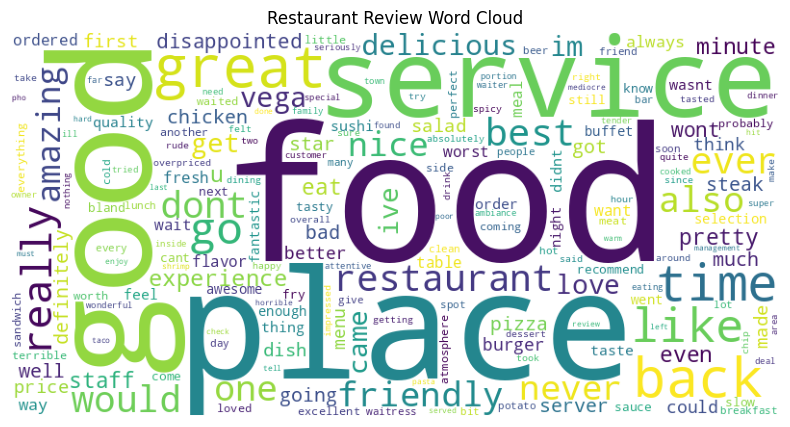

In [11]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Print topics and top 10 words
for idx, topic in lda_model.show_topics(num_topics=5, num_words=10, formatted=False):
    print(f"\nTopic {idx}:")
    print([word for word, prob in topic])

# Count word frequency in all processed reviews
all_words = [word for review in df['processed_review'] for word in review]

word_freq = Counter(all_words)

print("\nTop 20 words:")
print(word_freq.most_common(20))

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Restaurant Review Word Cloud")
plt.show()

### Reflection:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"

### ✍️ Your Response: 🔧
Topic 0 - Food and Service  
Topic 1 - Positive Dining Experience  
Topic 2 - Customer Return Experience  
Topic 3 - Restaurant Atmosphere  
Topic 4 - Quality and Value


## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### Reflection:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The model helped answer business questions about customer opinions, including overall sentiment, common review topics, and factors that influence customer satisfaction.

2. I would recommend that the restaurant focus on improving negative customer experiences, especially related to food quality and service. The restaurant can use customer feedback to improve menu items, staff training, and overall service.

3. Using an LLM could make the process faster and provide more detailed insights from reviews. However, Python models provide more control, transparency, and repeatable results. LLMs may also have higher costs and less consistency.

4. Analyze restaurant customer reviews to identify sentiment and major topics. Use the review text to classify positive, neutral, and negative opinions, identify common customer concerns, and provide business recommendations for improving customer satisfaction.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_10_text_analytics.ipynb"